In [1]:
import numpy as np
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix

cancer = load_breast_cancer()
X=cancer.data
y=cancer.target
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=10000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print("Accuracy:",accuracy_score(y_test, y_pred))
print("Confusion matrix:\n",confusion_matrix(y_test,y_pred))

Accuracy: 0.956140350877193
Confusion matrix:
 [[39  4]
 [ 1 70]]


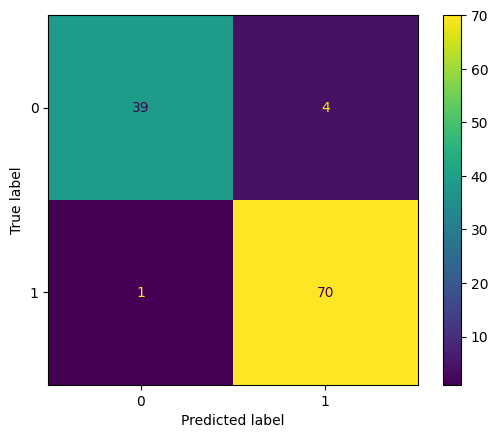

In [2]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ConfusionMatrixDisplay.from_predictions(y_test,y_pred)
plt.show()

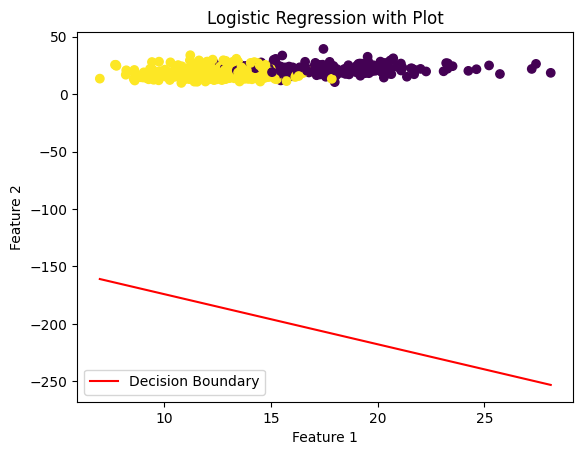

In [3]:
# Plot dataset points
plt.scatter(X[:,0], X[:,1], c=y)

# Decision boundary line
x1 = np.linspace(X[:,0].min(), X[:,0].max(), 100)
x2 = -(model.coef_[0][0]*x1 + model.intercept_[0]) / model.coef_[0][1]

plt.plot(x1, x2, color='red', label="Decision Boundary")

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression with Plot")
plt.legend()
plt.show()

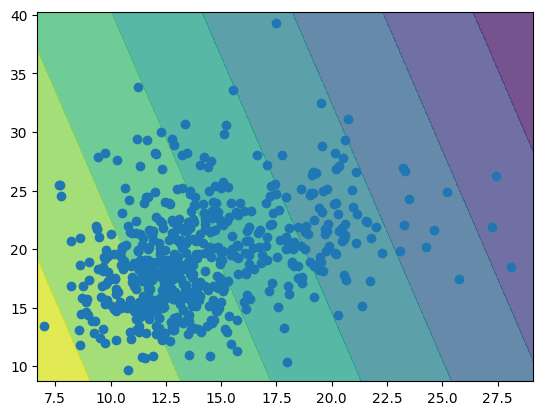

In [4]:
from sklearn.inspection import DecisionBoundaryDisplay
import matplotlib.pyplot as plt
X_set = X_train[:,:2]
y_set = y_train

model.fit(X_set,y_set)

DecisionBoundaryDisplay.from_estimator(model,X_set,alpha=0.75)
plt.scatter(X[:,0],X[:,1])